# Noções básicas de Estatística

A Estatística é um ramo da Matemática que tem um papel fundamental nas pesquisas científicas.

Vamos ver um exemplo onde a Estatística é utilizada.

Este exemplo é de um ramo da Estatística conhecido como **Inferência Estatística**.

Suponha que você queira saber a média das alturas dos brasileiros de 18 anos.

> O que você faria?

Uma maneira direta seria: medir a altura de todos os brasileiros de 18 anos e calcular a média.

> O que você acha disso?

Apesar desta maneira ser matematicamente correta, ela é totalmente inviável.

> Então, o que fazer?

Na prática, é possível trabalhar apenas com uma pequena parte da população. Essa pequena parte é chamada de amostra e iremos calcular a média apenas dessa amostra?

> Mas como saber se o que valor para a média da amostra é próximo da média da população?

Os métodos de Inferência Estatística nos auxiliam a decidir como escolher a amostra para que possamos obter um valor relevante para a média que queremos calcular.

Outro papel fundamental da Estatística é relacionado à descrição de dados. Isso é feito através de cálculos de funções estatísticas (como média, desvio padrão, etc), por representações gráficas, dentre outros.

Nesta unidade, o nosso foco será nessa parte da Estatística.

<hr>

# Média, mediana, quartis, moda


## Média e Mediana

Suponha que você fez uma prova e o professor disponibilizou uma planilha com notas.

Vamos importar a biblioteca e carregar a planilha:

In [1]:
import pandas as pd
df = pd.read_csv("https://drive.google.com/u/1/uc?id=16Xv85THn5BF1bBDDXLTT8nGxCP321QPv&export=download")
df

,Aluno,Nota
0,1,40.0
1,2,45.0
2,3,20.0
3,4,35.0
4,5,30.0
5,6,25.0
6,7,30.0
7,8,90.0
8,9,100.0
9,10,90.0


> Depois de ver a sua nota (claro :-D), o que você calcula para saber como a turma foi como um todo?

Em geral, calculamos a média. Então acessamos a coluna de notas e calculamos a média.

Para acessar a coluna de notas:

In [2]:
df["Nota"]

0     40.0
1     45.0
2     20.0
3     35.0
4     30.0
5     25.0
6     30.0
7     90.0
8    100.0
9     90.0
Name: Nota, dtype: float64

Para calcular a média:

In [3]:
df["Nota"].mean()

50.5

A média é uma **medida de tendência central**.

A partir de medidas de tendência central, tentamos descobrir os valores ***típicos*** dos dados.

> Mas, no nosso caso, você acha que a média que obtivemos descreve bem a nota  "típica"?

Vamos ver a planilha ordenada por nota:

In [4]:
df.sort_values(by="Nota")

,Aluno,Nota
2,3,20.0
5,6,25.0
4,5,30.0
6,7,30.0
3,4,35.0
0,1,40.0
1,2,45.0
7,8,90.0
9,10,90.0
8,9,100.0


Como você pode ver, temos 7 alunos com nota baixa e 3 alunos com nota muito alta.

Então, a média neste caso não descreve bem o que está acontecendo!

Uma outra medida de tendência central é a **mediana**:

Ela é calculada da seguinte maneira: após ordenarmos os dados

- Se a quantidade de dados for ímpar, a mediana é o valor exatamente na posição do meio.

- Se a quantidade de dados for par, a mediana é a média dos dois valores mais centrais.


Exemplo:
- para (3,4,6) , a mediana é 4
- para (1,2,3,4), a mediana é (2+3)/2 = 2.5

Temos
- $50\%$ dos dados $\leq$ a mediana
- $50\%$ dos dados $\geq$ a mediana.

Vamos calcular a mediana:

In [5]:
df["Nota"].median()

37.5

A mediana neste caso é muito mais baixa que a média!

Então note que a partir da média e da mediana juntas. Podemos deduzir que:

* A maioria dos alunos foi mal
* Uma minoria dos alunos foi muito bem (a ponto de puxar a média para cima)

### Exercício

Considere a planilha em:

https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download

Calcule a média e a mediana da temperatura.

Interprete o seu resultado.

In [20]:
# Sua resposta
df1 = pd.read_csv("https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download")
print(df1["temperatura"].mean())
print(df1["temperatura"].median())
print('A media e mediana da temperatura deram valores proximos, ou seja, a media descreve bem o que esta ocorrendo, pois o dado central condiz com o resultado da media das temperaturas, alem disso percebe-se que as temperaturas nao variam muito')


17.966666666666665
17.5
A media e mediana da temperatura deram valores proximos, ou seja, o codigo parece estar correto, pois o dado central condiz com o resultado da media das temperaturas, alem disso percebe-se que as temperaturas nao variam muito


## Percentis (quartis)

Uma forma mais detalhada para olhar a distribuição de dados são os **percentis**.

Existe mais de uma definição para percentis! Vamos apresentar uma das possibilidades.

Considere um conjunto de valores valores $v_1,v_2,\dotsc,v_{n}$ ordenados do menor para maior e um valor $P$ em $(0,100)$,
o $P$-ésimo **percentil** é o valor na posição $P(n+1)/100$.

Quando o valor posição não é um valor inteiro, o percentil é calculado a partir das posições inteiras mais próximas.

A ideia é calcular uma posição que separe os $P
\%$ menores valores dos maiores

Por exemplo, a ideia é que o $25$ᵒ percentil divida os 25% menores valores dos 75% valores maiores.

Os 25ᵒ, 50ᵒ e 75ᵒ percentis são chamados de quartis.

- O 25ᵒ percentil é chamado de primeiro quartil.
- O 50ᵒ percentil é chamado de segundo quartil.
- O 75ᵒ percentil é chamado de terceiro quartil.

Para calcular os percentis, utilizamos e a função percentile. Veja como ela funciona:

25ᵒ Percentil das notas:

In [21]:
import numpy as np    # precisamos de biblioteca numpy para calcular Percentil
df = pd.read_csv("https://drive.google.com/u/1/uc?id=16Xv85THn5BF1bBDDXLTT8nGxCP321QPv&export=download")
np.percentile(df["Nota"], q=25)

30.0

50ᵒ Percentil das notas:

In [22]:
np.percentile(df["Nota"],q=50)

37.5

75ᵒ Percentil das notas:

In [23]:
np.percentile(df["Nota"],q=75)

78.75

### Exercício

Considere a planilha em:

https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download

Calcule os percentis: 25ᵒ, 50ᵒ, 75ᵒ.

In [28]:
# Sua resposta
df2 = pd.read_csv("https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download")
print(np.percentile(df2["temperatura"], q=25))
print(np.percentile(df2["temperatura"], q=50))
print(np.percentile(df2["temperatura"], q=75))


15.0
17.5
20.0


## Moda

As modas de um conjunto de dados são os valores que aparecem com maior frequência.

Ou seja, os valores que estão "na moda".

Para calcular as modas, usamos a função ``mode()``:

In [29]:
df = pd.read_csv("https://drive.google.com/u/1/uc?id=16Xv85THn5BF1bBDDXLTT8nGxCP321QPv&export=download")
df["Nota"].mode()

0    30.0
1    90.0
Name: Nota, dtype: float64

Ou seja, as notas que apareceram com maior frequência foram 30 e 90.

OBS: Note que existem conjuntos com uma única moda.

### Exercício

Considere a planilha em:

https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download

Calcule as modas.

In [31]:
# Sua resposta
df3 = pd.read_csv("https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download")
df3["temperatura"].mode()


0    15
1    17
Name: temperatura, dtype: int64

<hr>

# Medidas de dispersão

Em contraste com as medidas que vimos até agora, as medidas de dispersão procuram saber o quão "espalhados" estão os dados e quais são os valores extremos.

> Se você parar para pensar em medidas muito simples para valores extremos, quais seriam elas?

Provavelmente você pensaria no mínimo e máximo.

In [32]:
df = pd.read_csv("https://drive.google.com/u/1/uc?id=16Xv85THn5BF1bBDDXLTT8nGxCP321QPv&export=download")
df["Nota"].min()

20.0

In [33]:
df["Nota"].max()

100.0

A diferença entre o maior valor e o menor valor é chamada de **amplitude**:

In [34]:
df["Nota"].max()-df["Nota"].min()

80.0

Uma medida de dispersão que usamos com frequência é a **variância**.

A variância busca medir a distância dos pontos em relação à média.

Para uma ideia intuitiva: quanto maior é a variância, mais espalhados estão nossos dados.

Por exemplo, se todos os valores são iguais, a variância é 0.


In [35]:
df["Nota"].var()

930.2777777777778

A definição de variância calcula as distâncias **ao quadrado** utilizando em relação à média.

Por isso, também olhamos com frequência o valor do **desvio padrão** que é simplesmente a raiz quadrada da variância.

In [36]:
df["Nota"].std()

30.50045537000682

O que você pode deduzir sobre as notas a partir do valor desvio padrão obtido; as notas são homogêneas?

### Exercício
Considere a planilha em:

https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download

Calcule para a temperatura as seguintes medidas:
- mínimo
- máximo
- amplitude
- variância
- desvio padrão

In [39]:
# Sua resposta
df4 = pd.read_csv("https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download")
print(df4["temperatura"].min())
print(df4["temperatura"].max())
print(df4["temperatura"].max()-df4["temperatura"].min())
print(df4["temperatura"].var())
print(df4["temperatura"].std())

12
26
14
13.61954022988506
3.69046612637009


Como as medidas que apresentamos são usadas muito frequentemente, existe uma função que as agrega:

In [40]:
df = pd.read_csv("https://drive.google.com/u/1/uc?id=16Xv85THn5BF1bBDDXLTT8nGxCP321QPv&export=download")
df["Nota"].describe()

count     10.000000
mean      50.500000
std       30.500455
min       20.000000
25%       30.000000
50%       37.500000
75%       78.750000
max      100.000000
Name: Nota, dtype: float64

<hr>

# Operações nas planilhas

É muito comum que tenhamos que adicionar colunas a uma planilha para fazer os cálculos que desejamos.

Suponha que queiramos criar uma nova coluna com nome "Calcula" e que, para cada aluno, o seu valor seja

$$(-1)^{\text{identificação do aluno}}\cdot (\text{nota do aluno})$$

Note que a nova coluna é automaticamente adicionada:

In [41]:
df = pd.read_csv("https://drive.google.com/u/1/uc?id=16Xv85THn5BF1bBDDXLTT8nGxCP321QPv&export=download")
df["Calcula"] = (-1)**df["Aluno"]*df["Nota"]
df

,Aluno,Nota,Calcula
0,1,40.0,-40.0
1,2,45.0,45.0
2,3,20.0,-20.0
3,4,35.0,35.0
4,5,30.0,-30.0
5,6,25.0,25.0
6,7,30.0,-30.0
7,8,90.0,90.0
8,9,100.0,-100.0
9,10,90.0,90.0


### Exercício

Considere a planilha em:

https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download

Crie uma nova coluna com o nome "razão" para qual o valor para cada período é a temperatura dividida pelo período.

Calcule sua média.

In [56]:
# Sua resposta
df5 = pd.read_csv("https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download")
df5["razao"] = df5["temperatura"]/df5["periodo"]
print(df5)
print(df5["razao"].mean())


    periodo  temperatura      razao
0         1           25  25.000000
1         2           24  12.000000
2         3           24   8.000000
3         4           26   6.500000
4         5           22   4.400000
5         6           20   3.333333
6         7           14   2.000000
7         8           13   1.625000
8         9           14   1.555556
9        10           12   1.200000
10       11           15   1.363636
11       12           17   1.416667
12       13           21   1.615385
13       14           20   1.428571
14       15           19   1.266667
15       16           20   1.250000
16       17           20   1.176471
17       18           17   0.944444
18       19           18   0.947368
19       20           18   0.900000
20       21           15   0.714286
21       22           17   0.772727
22       23           13   0.565217
23       24           15   0.625000
24       25           15   0.600000
25       26           17   0.653846
26       27           15   0

<hr>

# Gráficos

Criar gráficos para representar os nossos dados, pode ser muito útil para rapidamente obter informações.

Um gráfico muito simples é o **histograma** que divide os dados em categorias e apresenta quantos valores estão em cada categoria:

array([[<Axes: title={'center': 'Nota'}>]], dtype=object)

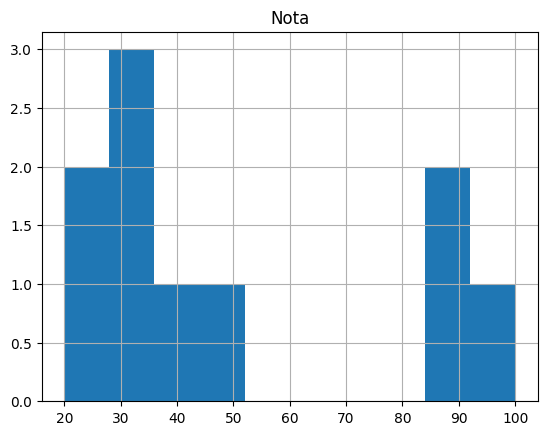

In [46]:
df = pd.read_csv("https://drive.google.com/u/1/uc?id=16Xv85THn5BF1bBDDXLTT8nGxCP321QPv&export=download")
df.hist(column="Nota")


Note como a partir dos histogramas, conseguimos rapidamente visualizar a performance dos alunos.

Por padrão são criadas 10 categorias.

No nosso caso, as categorias dividem os valores de 20 (menor nota) a 100 (maior nota) e cada categoria é formada por 8 notas.

Por exemplo, a primeira categoria são as notas de 20 a 28. A segunda até 36 (e assim por diante).

Podemos especificar o número de categorias. Veja um exemplo com apenas 2 categorias:

array([[<Axes: title={'center': 'Nota'}>]], dtype=object)

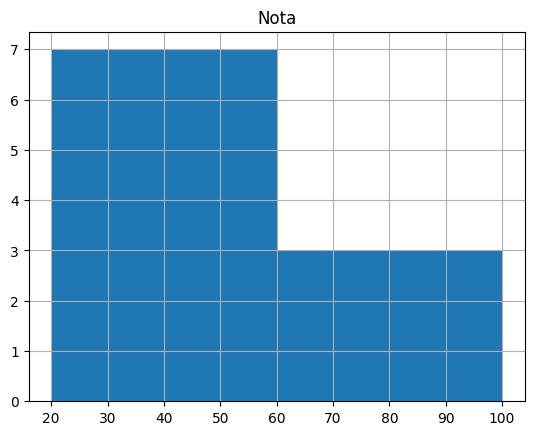

In [47]:
df.hist(column="Nota", bins=2)

Outro tipo de gráfico muito usado em Estatística é o box plot.

<Axes: >

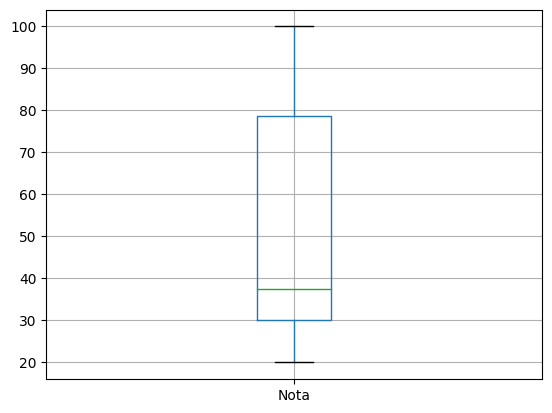

In [48]:
df.boxplot(column="Nota")

O box plot apresenta várias informações úteis:
- A linha verde dentro da caixa é a mediana
- A linha inferior da caixa é o primeiro quartil (Q1), ou seja, o 25 percentil.
- A linha superior da caixa é o terceiro quartil (Q3), ou seja, o 75 percentil.
- o traço inferior em preto é o menor valor nos dados que fica acima de $Q1-1.5 IQR$, onde $IQR = Q3-Q1$.
- o traço superior em preto é o maior valor nos dados fica abaixo de
$Q3+1.5 IQR$

O valor IQR é chamado de **amplitude interquartil**.

Pontos abaixo do traço inferior ou acima do traço superior são chamados de **discrepantes**.

No nosso caso, não havia pontos discrepantes. Quando eles existem, são representados por círculos.

Veja um exemplo:



<Axes: >

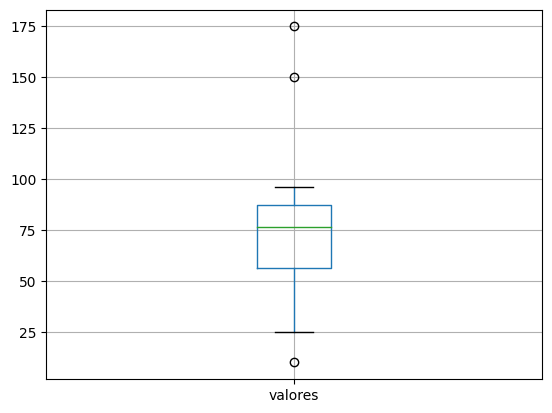

In [49]:
df = pd.read_csv("https://drive.google.com/u/1/uc?id=10yl6WEW0-PZKWYpkzGswvP3p105n831w&export=download")
df.boxplot(column="valores")

### Exercício

Considere a planilha em:

https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download

Crie para a temperatura:
- um histograma com $3$ categorias
- o boxplot


array([[<Axes: title={'center': 'temperatura'}>]], dtype=object)

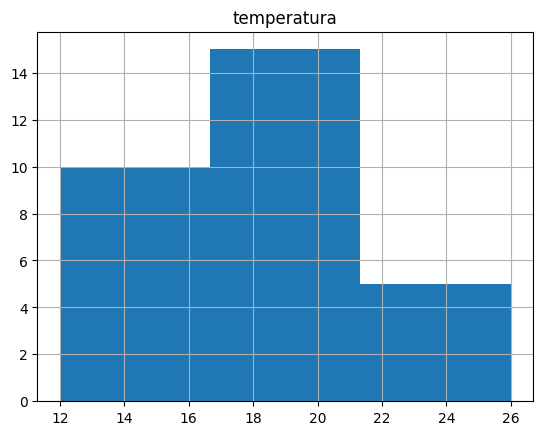

In [54]:
# Sua resposta
df6 = pd.read_csv("https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download")
df6.hist(column="temperatura", bins=3)

<Axes: >

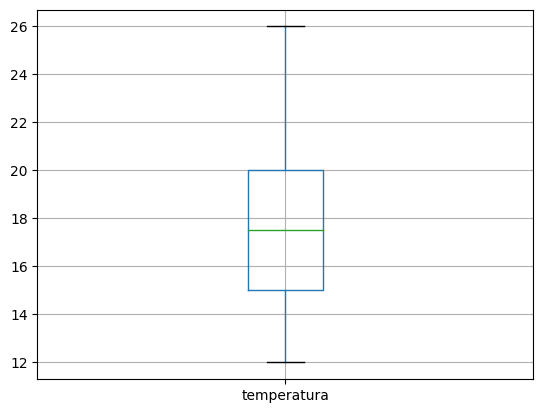

In [51]:
df7 =pd.read_csv("https://drive.google.com/u/1/uc?id=182_Z-bL7n9itkupECYhIOEGuIjfQbF0Z&export=download")
df7.boxplot(column="temperatura")